In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load the COVID-19 dataset
df = pd.read_csv("covid_19.csv")

In [ ]:
df.columns = df.columns.str.lower()
df.columns

Index(['country', 'continent', 'population', 'day', 'time', 'cases',
       'recovered', 'deaths', 'tests'],
      dtype='object')

In [ ]:
# Checking for missing values in each column
df.isnull().sum()

country        0
continent      2
population     9
day            0
time           0
cases          0
recovered     48
deaths         5
tests         25
dtype: int64

In [ ]:
df['continent'] = df['continent'].fillna('Unknown')
df = df.dropna(subset=['population'])

In [ ]:
# checking if there is a value "0"
(df == 0).any()

country       False
continent     False
population    False
day           False
time          False
cases         False
recovered     False
deaths        False
tests         False
dtype: bool

In [ ]:
# Filling missing values in specific columns with 0 as not reported
df['recovered'] = df['recovered'].fillna(0)
df['deaths'] = df['deaths'].fillna(0)
df['tests'] = df['tests'].fillna(0)

In [ ]:
# Checking for duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# Convert 'day' to datetime format
df['day'] = pd.to_datetime(df['day'])

In [ ]:
# Drop the 'time' column
df = df.drop(columns=['time'])

In [ ]:
# List of numeric columns
numeric_cols = ['cases', 'recovered', 'deaths', 'tests', 'population']

# Convert to numeric 
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # convert invalid data to NaN

df[numeric_cols] = df[numeric_cols].astype(int)

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary[col] = outlier_count

outlier_summary

{'population': 27, 'cases': 39, 'recovered': 39, 'deaths': 32, 'tests': 37}

In [ ]:
df_capped = df.copy()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_capped[col] = df[col].clip(lower, upper)

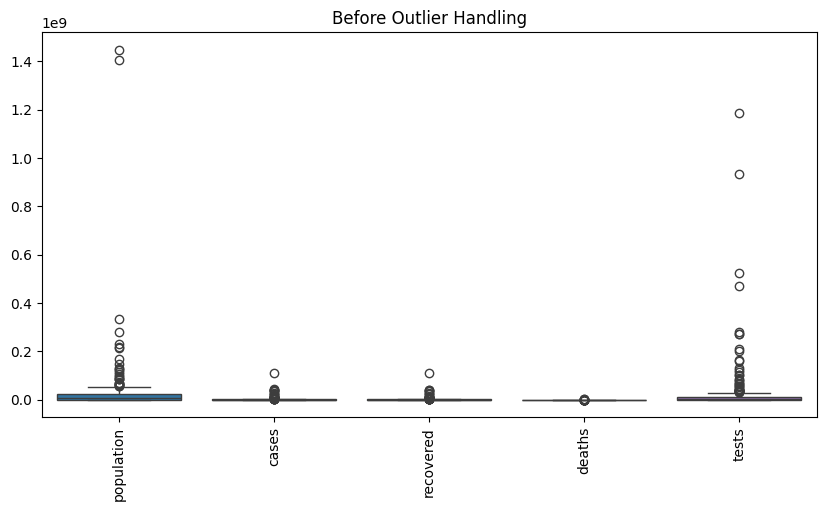

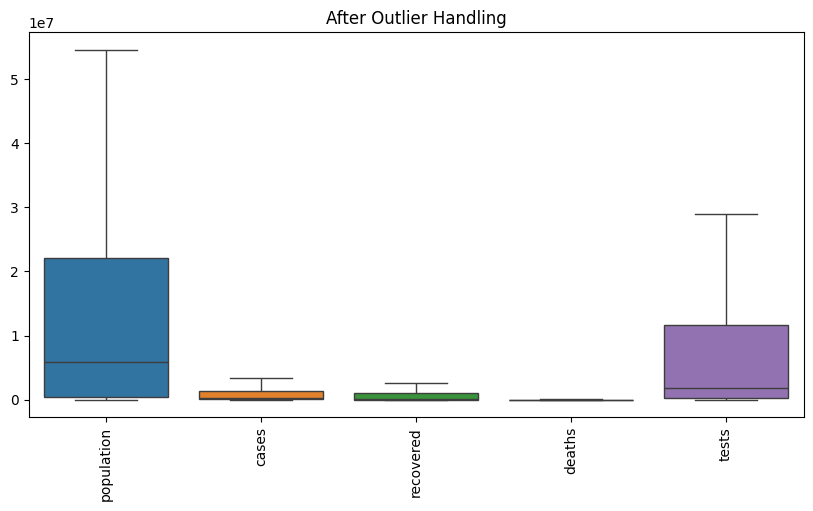

In [ ]:

plt.figure(figsize=(10,5))
sns.boxplot(data=df[numeric_cols])
plt.title("Before Outlier Handling")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df_capped[numeric_cols])
plt.title("After Outlier Handling")
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Replace original dataframe with the capped version for further analysis
df = df_capped.copy()

In [ ]:
# Mortality rate (% of cases that resulted in death)
df['mortality_rate'] = (df['deaths'] / df['cases']) * 100

# Recovery rate (% of cases that recovered)
df['recovery_rate'] = (df['recovered'] / df['cases']) * 100

# Active cases
df['active_cases'] = df['cases'] - df['recovered'] - df['deaths']
# Tests per 1000 population
df['tests_per_1000'] = (df['tests'] / df['population']) * 1000
df['tests_per_1000'] = df['tests_per_1000'].round(2)

# Cases per 1000 population
df['cases_per_1000'] = (df['cases'] / df['population']) * 1000
df['cases_per_1000'] = df['cases_per_1000'].round(2)

In [ ]:
df['positivity_rate'] = np.nan
mask = df['tests'] > 0
df.loc[mask, 'positivity_rate'] = (df.loc[mask, 'cases'] / df.loc[mask, 'tests']) * 100
df['positivity_rate'] = df['positivity_rate'].round(2)

In [ ]:
# min and max value of cases 
print(df['cases'].min())
print(df['cases'].max())

10
3350364


In [ ]:
# Calculate thresholds based on quartiles to maintain risk level distribution
Q1 = df['cases'].quantile(0.25)
Q2 = df['cases'].quantile(0.50)
Q3 = df['cases'].quantile(0.75)

def risk_level(cases):
    if cases <= Q1:
        return 'Low'
    elif cases <= Q2:
        return 'Medium'
    elif cases <= Q3:
        return 'High'
    else:
        return 'Very High'

df['risk_level'] = df['cases'].apply(risk_level)

In [ ]:
df['population'].describe()

count    2.290000e+02
mean     1.497076e+07
std      1.887019e+07
min      7.990000e+02
25%      4.454310e+05
50%      5.797805e+06
75%      2.210284e+07
max      5.458895e+07
Name: population, dtype: float64

In [ ]:
# Calculate thresholds based on quartiles to maintain population category distribution
Q1_pop = df['population'].quantile(0.25)
Q2_pop = df['population'].quantile(0.50)
Q3_pop = df['population'].quantile(0.75)

def population_category(pop):
    if pop <= Q1_pop:
        return 'Very Small'
    elif pop <= Q2_pop:
        return 'Small'
    elif pop <= Q3_pop:
        return 'Medium'
    else:
        return 'Large'

df['population_category'] = df['population'].apply(population_category)


In [ ]:
# Group data by continent and calculate total cases, deaths, recovered, and tests for each continent
continent_stats = df.groupby('continent').agg({
    'cases': 'sum',
    'deaths': 'sum',
    'recovered': 'sum',
    'tests': 'sum'
}).reset_index()
continent_stats

,continent,cases,deaths,recovered,tests
0,Africa,12134825,192143.5,7880316,111032578
1,Asia,74285445,673616.5,45387252,692563528
2,Europe,82086781,792917.5,61453741,654997256
3,North-America,17471243,190001.5,12631558,130150863
4,Oceania,6392991,33015.0,5344320,38683898
5,South-America,21722243,274289.0,16780508,164221045


In [ ]:
# Rank countries by cases, deaths, and active cases (1 = highest value)
df['cases_rank'] = df['cases'].rank(ascending=False)
df['deaths_rank'] = df['deaths'].rank(ascending=False)
df['active_rank'] = df['active_cases'].rank(ascending=False)

In [ ]:
import sqlite3

# Create connection to SQLite database (creates file if it doesn't exist)
conn = sqlite3.connect('covid_data.db')

# Load the dataframe into SQLite table
df.to_sql('covid_cleaned', conn, if_exists='replace', index=False)

print(f"Data loaded successfully!")
print(f"Total records: {len(df)}")
print(f"Columns: {list(df.columns)}")

# Close connection
conn.close()

Data loaded successfully!
Total records: 229
Columns: ['country', 'continent', 'population', 'day', 'cases', 'recovered', 'deaths', 'tests', 'mortality_rate', 'recovery_rate', 'active_cases', 'tests_per_1000', 'cases_per_1000', 'positivity_rate', 'risk_level', 'population_category', 'cases_rank', 'deaths_rank', 'active_rank']
